# Notebook 2 — IC Toward a River / Lake Target (GEE/xee)
### GeomorphConn · Singh et al. (2026)

This notebook computes **IC-target** relative to a river/lake target feature while keeping raster inputs cloud-native through GEE/xee.

### Inputs
- Required: target vector (shapefile/geojson/gpkg) to define target nodes
- Optional: explicit bounds tuple (otherwise target extent is used)
- Optional: local DEM override (if not provided, DEM is fetched from GEE)

### Workflow
1. Fetch DEM/NDVI/rainfall from GEE for the target region
2. Build Landlab grid and rasterize target feature
3. Run IC-outlet and IC-target across weight scenarios (DEM-only and combinations)
4. Compare and export results with matplotlib visualizations

### Roughness reference
The DEM roughness weighting used here follows the residual roughness approach of:
Cavalli, M., and Marchi, L. (2008). *Characterisation of the surface morphology of an alpine alluvial fan using airborne LiDAR*. Natural Hazards and Earth System Sciences, 8(2), 323-333. https://doi.org/10.5194/nhess-8-323-2008


### Installation

See: [Installation](https://github.com/manudeo/GeomorphConn/blob/main/INSTALLATION.md)

Quick install:
```bash
conda create -n geomorphconn python=3.11
conda activate geomorphconn
git clone https://github.com/manudeo/GeomorphConn.git
cd GeomorphConn
pip install -e ".[all]"
```

## 0 · Configuration

In [3]:
from pathlib import Path

# ── Required target vector ───────────────────────────────────────────────────
TARGET_PATH = Path("Target_example.shp")  # shapefile/geojson/gpkg/etc.
if not TARGET_PATH.exists():
    raise FileNotFoundError(f"Target vector not found: {TARGET_PATH}")

# ── Region bounds (optional) ─────────────────────────────────────────────────
# If None, fetch region is inferred from TARGET_PATH extent
# Format: (lon_min, lat_min, lon_max, lat_max) = (West, South, East, North) in WGS-84
BOUNDS =  (76.09556906553738, 24.867882347223897, 76.52756888567045, 25.178609604000833) #<-- Chambal

# ── Optional local DEM override (otherwise fetched from GEE) ────────────────
DEM_OVERRIDE_PATH = None  # e.g., Path("data/dem.tif")

# ── GEE configuration ────────────────────────────────────────────────────────
GEE_PROJECT = "drylands-aberuni"
DEM_SOURCE = "COPDEM30"
RF_SOURCE = "CHIRPS"                  # CHIRPS | ERA5 (~11 km) | PERSIANN (~28 km)
NDVI_SOURCE = "SENTINEL2"            # SENTINEL2 (~10 m) | LANDSAT8 (~30 m) | LANDSAT9 (~30 m)
START_DATE = "2020-05-01"
END_DATE = "2020-09-30"
# Use a projected CRS in meters. Replace with your local UTM CRS for best results.
# EPSG:4326 can collapse small bboxes to 1×1 pixels when used with xee + metric scale.
CRS = "EPSG:32643" # <--UTM 43N - Chambal

# Note: Set SCALE with the coarsest input dataset in mind.
# CHIRPS is ~5.5 km, so for very small regions use a coarser SCALE or a wider bbox.
SCALE = 30

# ── IC / weighting options ───────────────────────────────────────────────────
FLOW_DIRECTOR = "DINF"                 # D8 | DINF | MFD (uppercase)
WEIGHT_SCENARIOS = [
    "roughness_only",
    "rainfall_only",
    "ndvi_only",
    "ndvi_rainfall",
    "ndvi_rainfall_roughness",
]
PLOT_SCENARIO = "ndvi_rainfall"

OUTPUT_DIR = Path("output_nb2")
OUTPUT_DIR.mkdir(exist_ok=True)
print('Configuration done.')

Configuration done.


## 1 · Imports

In [4]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from landlab import RasterModelGrid

from geomorphconn.components import ConnectivityIndex
from geomorphconn.utils import rasterize_targets
from geomorphconn.gee import GEEFetcher
from geomorphconn.weights import (
    WeightBuilder,
    NDVIWeight,
    RainfallWeight,
    preset_rainfall_ndvi,
    preset_rainfall_ndvi_roughness,
    preset_roughness_only,
)

print("All imports successful.")

All imports successful.


In [5]:
# Reproducibility snapshot (timestamp + package versions)
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version

def _pkg_version(name: str) -> str:
    try:
        return version(name)
    except PackageNotFoundError:
        return "not-installed"

print("Run timestamp (UTC):", datetime.now(timezone.utc).isoformat())
for pkg in [
    "geomorphconn",
    "numpy",
    "pandas",
    "matplotlib",
    "rasterio",
    "geopandas",
    "landlab",
]:
    print(f"{pkg:12s}: {_pkg_version(pkg)}")

Run timestamp (UTC): 2026-04-14T14:05:04.648060+00:00
geomorphconn: 0.1.0
numpy       : 2.2.6
pandas      : 2.3.3
matplotlib  : 3.10.8
rasterio    : 1.4.4
geopandas   : 1.1.3
landlab     : 2.9.2


## 2 · Fetch raster inputs from GEE (optional local DEM override)

GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : None (not fetched)
  Period     : 2020-05-01 → 2020-09-30
  Scale      : 30 m  |  CRS: EPSG:32643
Fetching DEM …
  DEM shape: 1161×1442, range: 214.2–326.3 m
Fetching NDVI …
  NDVI shape: (1161, 1442), range: -0.149–0.709
Fetching Rainfall …
  Rainfall shape: (1161, 1442), range: 709.74–804.39
Fetched rasters: 1161x1442, dx=30.0 m


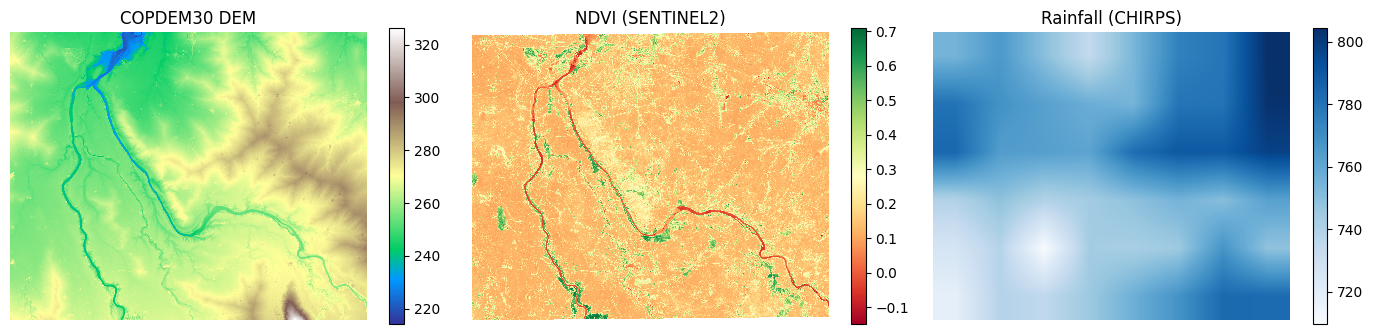

In [6]:
def _load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float64)
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile

bounds_input = BOUNDS if BOUNDS is not None else str(TARGET_PATH)

fetcher = GEEFetcher(
    bounds=bounds_input,
    dem_source=DEM_SOURCE,
    rainfall_source=RF_SOURCE,
    ndvi_source=NDVI_SOURCE,
    start_date=START_DATE,
    end_date=END_DATE,
    scale=SCALE,
    crs=CRS,
    gee_project=GEE_PROJECT,
)

dem, ndvi, rainfall, profile = fetcher.fetch()

if DEM_OVERRIDE_PATH is not None and Path(DEM_OVERRIDE_PATH).exists():
    dem, dem_profile = _load_raster(Path(DEM_OVERRIDE_PATH))
    profile.update({
        "transform": dem_profile["transform"],
        "width": dem_profile["width"],
        "height": dem_profile["height"],
        "crs": dem_profile["crs"],
    })
    print(f"Using DEM override: {DEM_OVERRIDE_PATH}")

nrows, ncols = dem.shape
dx = abs(profile["transform"].a)

if nrows <= 1 or ncols <= 1:
    raise ValueError(
        "Fetched a 1x1 grid. Use a projected CRS (for example local UTM, not EPSG:4326), "
        "increase the bbox size, or use a coarser SCALE that matches the source resolution."
    )

import geopandas as gpd
target_gdf = gpd.read_file(TARGET_PATH)

print(f"Fetched rasters: {nrows}x{ncols}, dx={dx:.1f} m")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=100)
for ax, arr, title, cmap in zip(
    axes,
    [dem, ndvi, rainfall],
    [f"{DEM_SOURCE} DEM", f"NDVI ({NDVI_SOURCE})", f"Rainfall ({RF_SOURCE})"],
    ["terrain", "RdYlGn", "Blues"],
):
    im = ax.imshow(arr, cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3 · Build Landlab grid

In [7]:
def arr_to_node(arr):
    """Flip (GeoTIFF → Landlab) and ravel to 1D node array."""
    a = np.flipud(arr).copy()
    a[np.isnan(a)] = 0.0
    return a.ravel()

dem_ll = np.flipud(dem).copy()
dem_ll[np.isnan(dem_ll)] = np.nanmin(dem_ll) - 1.0

# Create RasterModelGrid WITH geographic coordinates (not at origin 0,0)
# Extract bounds from profile's geospatial transform
tr = profile["transform"]
lon_min = tr.c                                      # x-coord of upper-left
lat_min = tr.f - nrows * abs(tr.e)                 # y-coord of lower-left
xy_spacing = abs(tr.a)                             # pixel width in metres

grid = RasterModelGrid(
    (nrows, ncols),
    xy_spacing=xy_spacing,
    xy_of_lower_left=(lon_min, lat_min)  # Real geographic coordinates
)
grid.add_field("topographic__elevation", dem_ll.ravel(), at="node")

ndvi_ll     = arr_to_node(ndvi)
rainfall_ll = arr_to_node(rainfall)

print(f"Grid: {grid.number_of_nodes:,} nodes")
print(f"  Grid bounds: ({grid.x_of_node.min():.2f}, {grid.y_of_node.min():.2f}) to ({grid.x_of_node.max():.2f}, {grid.y_of_node.max():.2f})")

Grid: 1,674,162 nodes
  Grid bounds: (610675.87, 2750763.69) to (653905.87, 2785563.69)


## 4 · Rasterize target features

`rasterize_targets` converts the vector river/lake geometry to a list of Landlab node IDs, replicating ArcGIS *PolygonToRaster → SetNull → impose-on-FDR* steps in one call.

Target nodes: 10,359  (0.6% of grid)


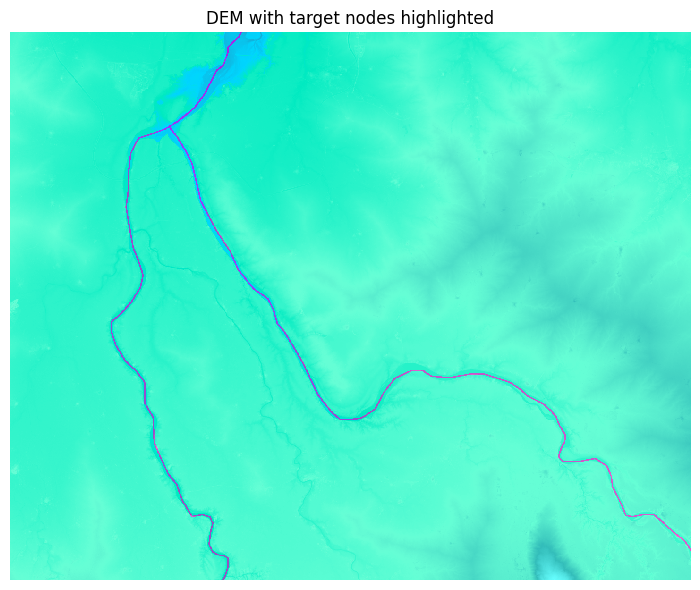

In [8]:
target_nodes = rasterize_targets(
    source        = target_gdf,
    grid          = grid,
    dem_transform = profile["transform"],
    dem_crs       = profile["crs"],
    buffer_m      = dx,    # 1-cell buffer to ensure narrow lines are captured
)

print(f"Target nodes: {len(target_nodes):,}  "
      f"({100*len(target_nodes)/grid.number_of_nodes:.1f}% of grid)")

# Visualise target overlay on DEM
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.imshow(dem, cmap="terrain", aspect="equal", interpolation="nearest")
# Mark target cells
target_mask_2d = np.zeros(grid.number_of_nodes, dtype=bool)
target_mask_2d[target_nodes] = True
ax.imshow(np.flipud(target_mask_2d.reshape(nrows, ncols)),
          cmap="cool", alpha=0.6, aspect="equal", interpolation="nearest")
ax.set_title("DEM with target nodes highlighted"); ax.axis("off")
plt.tight_layout(); plt.show()

## 5 · Run IC-outlet and IC-target across weight scenarios

In [14]:
import time

def arr_to_node(arr):
    a = np.flipud(arr).copy()
    a[np.isnan(a)] = 0.0
    return a.ravel()

def build_fresh_grid(dem_arr, dx_val):
    dem_ll_local = np.flipud(dem_arr).copy()
    dem_ll_local[np.isnan(dem_ll_local)] = np.nanmin(dem_ll_local) - 1.0
    g = RasterModelGrid(dem_arr.shape, xy_spacing=dx_val)
    g.add_field("topographic__elevation", dem_ll_local.ravel(), at="node")
    return g

def make_weight_builder(name, rainfall_nodes, ndvi_nodes, grid_obj):
    if name == "roughness_only":
        return preset_roughness_only(grid_obj)
    if name == "rainfall_only":
        return WeightBuilder().add(RainfallWeight(rainfall_nodes))
    if name == "ndvi_only":
        return WeightBuilder().add(NDVIWeight(ndvi_nodes))
    if name == "ndvi_rainfall":
        return preset_rainfall_ndvi(rainfall_nodes, ndvi_nodes)
    if name == "ndvi_rainfall_roughness":
        return preset_rainfall_ndvi_roughness(rainfall_nodes, ndvi_nodes, grid_obj)
    raise ValueError(f"Unknown scenario: {name}")

def run_ic_once(mode, scenario):
    grid_local = build_fresh_grid(dem, dx)
    ndvi_nodes_local = arr_to_node(ndvi)
    rainfall_nodes_local = arr_to_node(rainfall)
    
    wb_local = make_weight_builder(
    scenario,
    rainfall_nodes_local,
    ndvi_nodes_local,
    grid_local,
    )
    
    kwargs = dict(
    flow_director=FLOW_DIRECTOR,
    weight=wb_local,
    )
    if mode == "target":
        kwargs["target_nodes"] = target_nodes
    
    ic_local = ConnectivityIndex(grid_local, **kwargs)
    t0 = time.time()
    ic_local.run_one_step()
    runtime_s = time.time() - t0
    
    return {
    "IC": ic_local.as_2d().copy(),
    "W": ic_local.as_2d("connectivity_index__W").copy(),
    "Dup": ic_local.as_2d("connectivity_index__Dup").copy(),
    "Ddn": ic_local.as_2d("connectivity_index__Ddn").copy(),
    "runtime_s": runtime_s,
    }
ic_outlet_results = {}
ic_target_results = {}

for scenario in WEIGHT_SCENARIOS:
    ic_outlet_results[scenario] = run_ic_once("outlet", scenario)
    ic_target_results[scenario] = run_ic_once("target", scenario)

summary_rows = []
for scenario in WEIGHT_SCENARIOS:
    v_out = ic_outlet_results[scenario]["IC"]
    v_tgt = ic_target_results[scenario]["IC"]
    v_out = v_out[np.isfinite(v_out)]
    v_tgt = v_tgt[np.isfinite(v_tgt)]
    summary_rows.append({
    "scenario": scenario,
    "outlet_median": float(np.median(v_out)),
    "target_median": float(np.median(v_tgt)),
    "delta_median": float(np.median(v_tgt) - np.median(v_out)),
    "runtime_outlet_s": float(ic_outlet_results[scenario]["runtime_s"]),
    "runtime_target_s": float(ic_target_results[scenario]["runtime_s"]),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("scenario")
display(summary_df.round(4))

,scenario,outlet_median,target_median,delta_median,runtime_outlet_s,runtime_target_s
2,ndvi_only,-7.6042,-7.2596,0.3446,151.2613,149.1829
3,ndvi_rainfall,-7.5239,-7.1138,0.4101,150.3214,151.2338
4,ndvi_rainfall_roughness,-7.2562,-6.8597,0.3965,150.7447,151.0351
1,rainfall_only,-7.4995,-7.0102,0.4893,151.4013,153.2897
0,roughness_only,-6.9026,-6.5123,0.3903,151.6751,151.3636


## 6 · Compare IC-outlet vs IC-target

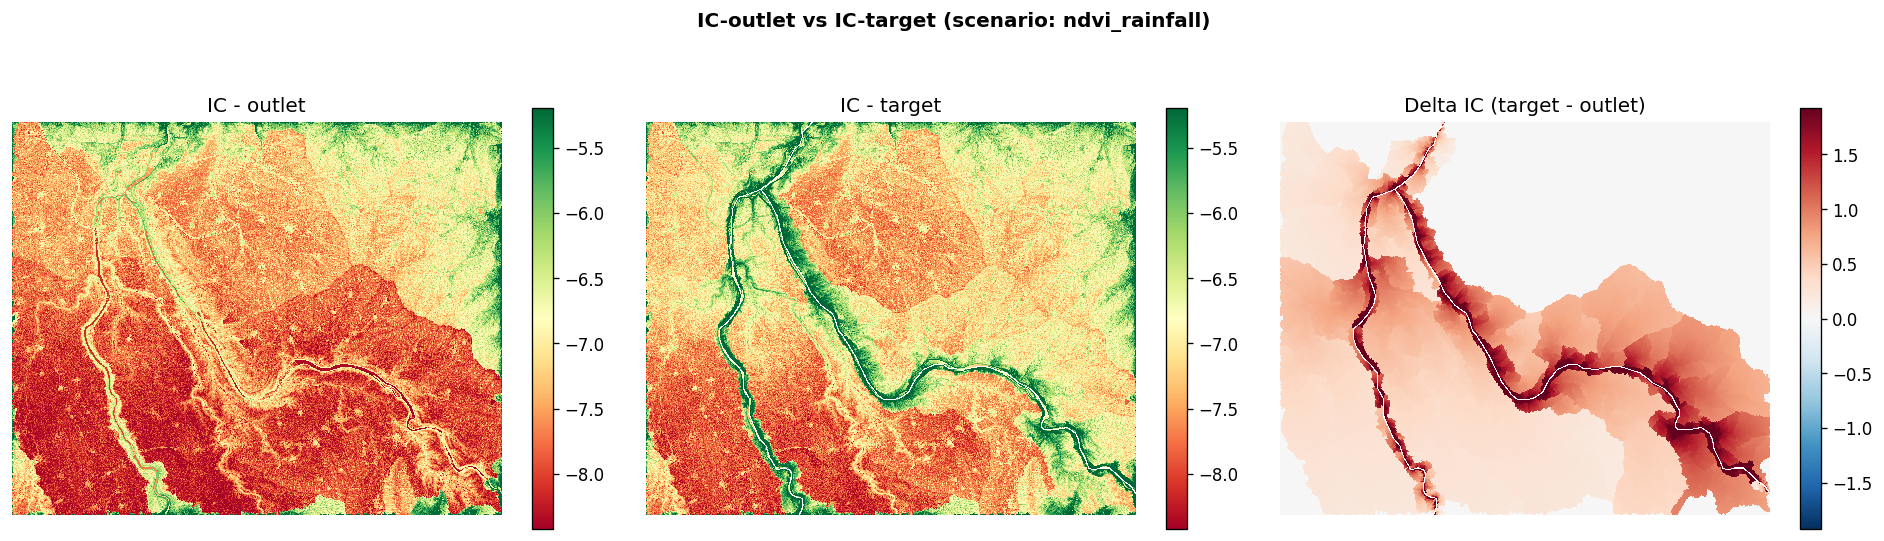

In [16]:
IC_outlet = ic_outlet_results[PLOT_SCENARIO]["IC"]
IC_target = ic_target_results[PLOT_SCENARIO]["IC"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)
fig.suptitle(
    f"IC-outlet vs IC-target (scenario: {PLOT_SCENARIO})",
    fontweight="bold"
 )

all_vals = np.concatenate([IC_outlet[np.isfinite(IC_outlet)], IC_target[np.isfinite(IC_target)]])
vmin, vmax = np.nanpercentile(all_vals, 2), np.nanpercentile(all_vals, 98)

for ax, arr, title in zip(
    axes,
    [IC_outlet, IC_target, IC_target - IC_outlet],
    ["IC - outlet", "IC - target", "Delta IC (target - outlet)"],
):
    kw = dict(interpolation="nearest", aspect="equal")
    if "Delta" in title:
        lim = max(abs(np.nanpercentile(arr, 2)), abs(np.nanpercentile(arr, 98)))
        im = ax.imshow(arr, cmap="RdBu_r", vmin=-lim, vmax=lim, **kw)
    else:
        im = ax.imshow(arr, cmap="RdYlGn", vmin=vmin, vmax=vmax, **kw)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "IC_outlet_vs_target.png", dpi=120, bbox_inches="tight")
plt.show()

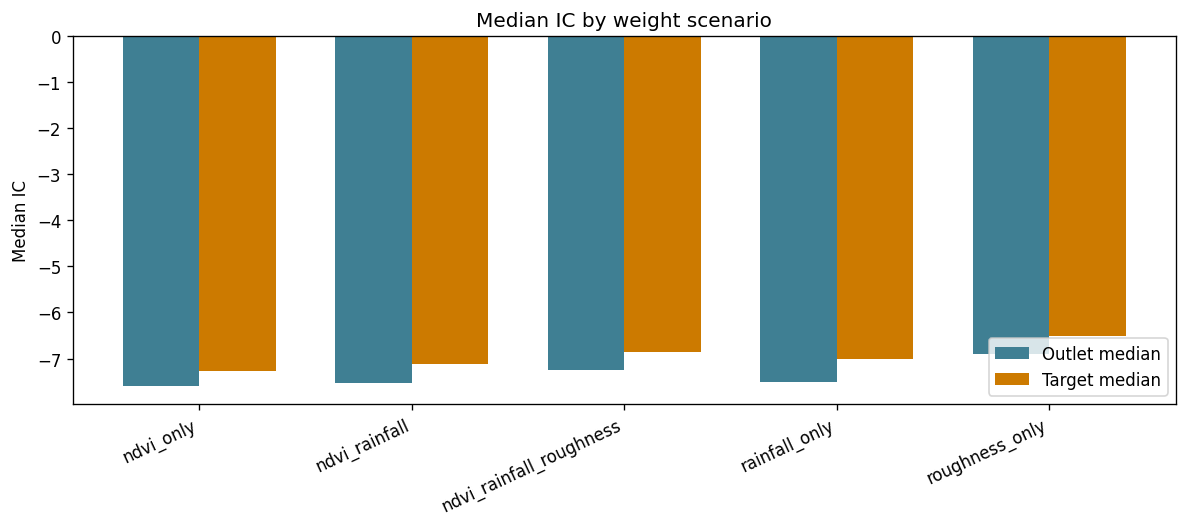

,scenario,outlet_median,target_median,delta_median,runtime_outlet_s,runtime_target_s
2,ndvi_only,-7.6042,-7.2596,0.3446,151.2613,149.1829
3,ndvi_rainfall,-7.5239,-7.1138,0.4101,150.3214,151.2338
4,ndvi_rainfall_roughness,-7.2562,-6.8597,0.3965,150.7447,151.0351
1,rainfall_only,-7.4995,-7.0102,0.4893,151.4013,153.2897
0,roughness_only,-6.9026,-6.5123,0.3903,151.6751,151.3636


In [18]:
# Scenario-level summary plot (matplotlib)
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)

x = np.arange(len(summary_df))
width = 0.36
ax.bar(x - width/2, summary_df["outlet_median"], width=width, label="Outlet median", color="#3f7f93")
ax.bar(x + width/2, summary_df["target_median"], width=width, label="Target median", color="#cc7a00")

ax.set_xticks(x)
ax.set_xticklabels(summary_df["scenario"], rotation=25, ha="right")
ax.set_ylabel("Median IC")
ax.set_title("Median IC by weight scenario")
ax.legend()
plt.tight_layout()
plt.show()

display(summary_df.round(4))
summary_df.to_csv(OUTPUT_DIR / "weight_scenarios_summary.csv", index=False)

In [19]:
# QC assertions before export
assert len(target_nodes) > 0, "No target nodes were rasterized."
assert PLOT_SCENARIO in ic_outlet_results, f"Missing outlet scenario: {PLOT_SCENARIO}"
assert PLOT_SCENARIO in ic_target_results, f"Missing target scenario: {PLOT_SCENARIO}"

IC_outlet = ic_outlet_results[PLOT_SCENARIO]["IC"]
IC_target = ic_target_results[PLOT_SCENARIO]["IC"]
IC_delta = IC_target - IC_outlet

for name, arr in {"IC_outlet": IC_outlet, "IC_target": IC_target, "IC_delta": IC_delta}.items():
    finite_frac = float(np.isfinite(arr).mean())
    assert finite_frac > 0.0, f"{name} has no finite values."
    print(f"{name}: finite fraction = {finite_frac:.3f}")

assert np.nanstd(IC_target[np.isfinite(IC_target)]) > 0.0, "IC_target appears constant."
print(f"QC passed: {len(target_nodes):,} target nodes and valid IC outputs.")

IC_outlet: finite fraction = 0.997
IC_target: finite fraction = 0.991
IC_delta: finite fraction = 0.991
QC passed: 10,359 target nodes and valid IC outputs.


## 7 · Export GeoTIFFs

In [20]:
def save_tiff(arr, path, profile):
    out = arr.astype(np.float32)
    out[~np.isfinite(out)] = -9999.0
    p   = profile.copy()
    p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    with rasterio.open(path, "w", **p) as dst:
        dst.write(out, 1)
    print(f"  ✓ {path}")

save_tiff(IC_outlet,                          OUTPUT_DIR / f"IC_outlet_{PLOT_SCENARIO}.tif", profile)
save_tiff(IC_target,                          OUTPUT_DIR / f"IC_target_{PLOT_SCENARIO}.tif", profile)
save_tiff(IC_target - IC_outlet,              OUTPUT_DIR / f"IC_delta_{PLOT_SCENARIO}.tif",  profile)
save_tiff(ic_target_results[PLOT_SCENARIO]["W"],   OUTPUT_DIR / f"W_{PLOT_SCENARIO}.tif",   profile)
save_tiff(ic_target_results[PLOT_SCENARIO]["Dup"], OUTPUT_DIR / f"Dup_{PLOT_SCENARIO}.tif", profile)
save_tiff(ic_target_results[PLOT_SCENARIO]["Ddn"], OUTPUT_DIR / f"Ddn_{PLOT_SCENARIO}.tif", profile)

summary_df.to_csv(OUTPUT_DIR / "weight_scenarios_summary.csv", index=False)
print("\nAll outputs saved to:", OUTPUT_DIR.resolve())

  ✓ output_nb2/IC_outlet_ndvi_rainfall.tif
  ✓ output_nb2/IC_target_ndvi_rainfall.tif
  ✓ output_nb2/IC_delta_ndvi_rainfall.tif
  ✓ output_nb2/W_ndvi_rainfall.tif
  ✓ output_nb2/Dup_ndvi_rainfall.tif
  ✓ output_nb2/Ddn_ndvi_rainfall.tif

All outputs saved to: /mnt/e/SideResearch/softwares/IndexOfConnectivity/sedconn_v3/sedconn/notebooks/output_nb2


## 8 · Notes on IC-target interpretation

**IC-outlet** quantifies how connected a cell is to the basin's natural outlet.  
**IC-target** quantifies how connected a cell is to the *nearest point on the river network* (or any other target feature).

For hillslope–channel coupling studies, IC-target is more physically meaningful because:
- Sediment eroded from a hillslope typically reaches a channel long before it reaches the basin outlet.
- The difference map (Δ IC = IC-target − IC-outlet) highlights cells where the presence of the river network *significantly alters* apparent connectivity.

In ArcGIS Pro, this workflow is available in `ConnectivityTools.atbx` using `ICtargetwithNDVIRFweightCalc` (`arcgis_tools/`).  
Both tools are described in Singh et al. (2026), *JOSS* (pending submission).